In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
from torch.utils.data import DataLoader , Dataset
from torchvision import transforms
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


torch.manual_seed(999)

<div style="background-color: yellow; color: black; padding: 5px 5px; border-radius: 20px; text-align: center;font-weight: bold; font-size: 40px; margin: 20px 0;">
  Step 1 | Data Preprocess and Loader
</div>

# Set Hyperparameter 

In [ ]:
hyperparameter = {'LEARNING_RATE' : 2e-4,
                  'BATCH_SIZE' : 128,
                  "IMAGE_SIZE" :64,
                  "CHANNELS_IMG" : 1,
                  "NOISE_DIM" : 100,
                  'NUM_EPOCHS' :10,
                  'FEATURES_DISC' : 64,
                  'FEATURES_GEN' :64,
                  'BETA_1':0.5,
                  'BETA_2':0.999}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

1. **Defines BanglaDigitDataset class to load Bangla digit images (0-9) from root directory.**
1. **Applies transformations: resizing, tensor conversion, and normalization.**
1. **Sets up DataLoader for batch processing.**

In [ ]:
class BanglaDigitDataset(Dataset):
    def __init__(self, root_dir, transform=None, threshold=128):
        self.root_dir = root_dir
        self.transform = transform
        self.threshold = threshold
        self.image_paths = []
        self.labels = []

        # Load image paths and labels
        for label in range(10):
            label_dir = os.path.join(root_dir, str(label))
            for img_name in os.listdir(label_dir):
                img_path = os.path.join(label_dir, img_name)
                self.image_paths.append(img_path)
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('L') 

        image = Image.fromarray(255 - np.array(image)) # inverted color

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose(
    [
        transforms.Resize((hyperparameter['IMAGE_SIZE'],hyperparameter['IMAGE_SIZE'])),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.5],[0.5]
        ),
    ]
)


dataset = BanglaDigitDataset(root_dir="/kaggle/input/bengali-digits/bengali_digits", transform=transform)
dataloader = DataLoader(dataset, batch_size=hyperparameter['BATCH_SIZE'], shuffle=True)

## Visualize

In [ ]:
for images, labels in dataloader:
    print(images.shape, labels[0])
    plt.imshow(images[0][0],cmap='gray')
#     print(images[0][0])
    break

<div style="background-color: yellow; color: black; padding: 5px 5px; border-radius: 20px; text-align: center;font-weight: bold; font-size: 40px; margin: 20px 0;">
  Step 2 | Create Model 
</div>

# DCGAN
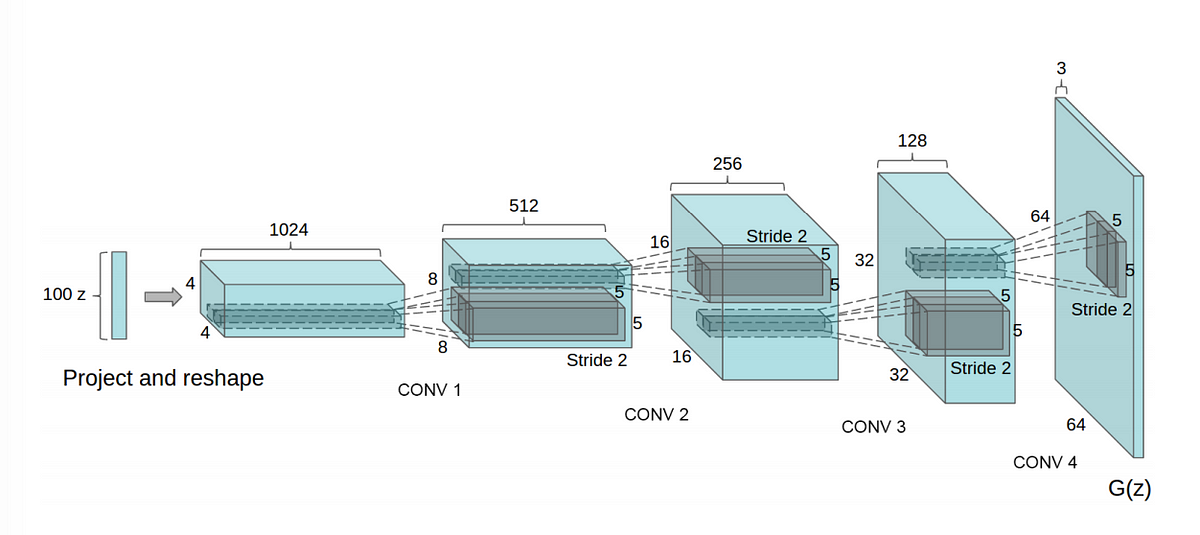

## Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            #project and reshape
            self._block(z_dim, features_g * 16, 4, 1, 0),  # img: 4x4
            #conv1
            self._block(features_g * 16, features_g * 8, 4, 2, 1),  # img: 8x8
            #conv2
            self._block(features_g * 8, features_g * 4, 4, 2, 1),  # img: 16x16
            #conv3
            self._block(features_g * 4, features_g * 2, 4, 2, 1),  # img: 32x32
            #conv4
            nn.ConvTranspose2d(
                features_g * 2, channels_img, kernel_size=5, stride=2, padding=1
            ),
            nn.Tanh(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.gen(x)

## Discriminator same config just reverse

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            nn.Conv2d(channels_img, features_d, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 4, 2, 1),
            self._block(features_d * 2, features_d * 4, 4, 2, 1),
            self._block(features_d * 4, features_d * 8, 4, 2, 1),
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=2, padding=0),
            nn.Sigmoid(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        return self.disc(x)

<div style="background-color: yellow; color: black; padding: 5px 5px; border-radius: 20px; text-align: center;font-weight: bold; font-size: 40px; margin: 20px 0;">
  Step 3 | Training   
</div>

## **Weights** for stable training

In [ ]:
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

In [ ]:
gen = Generator(hyperparameter['NOISE_DIM'], hyperparameter['CHANNELS_IMG'],hyperparameter['FEATURES_GEN']).to(device)
disc = Discriminator(hyperparameter['CHANNELS_IMG'], hyperparameter['FEATURES_GEN']).to(device)
gen=gen.apply(initialize_weights)
disc=disc.apply(initialize_weights)

opt_gen = optim.Adam(gen.parameters(), lr=hyperparameter['LEARNING_RATE'], betas=(hyperparameter['BETA_1'],hyperparameter['BETA_2']))
opt_disc = optim.Adam(disc.parameters(), lr=hyperparameter['LEARNING_RATE'], betas=(hyperparameter['BETA_1'],hyperparameter['BETA_2']))
criterion = nn.BCELoss()

In [ ]:
import wandb
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch

# # Initialize WandB
# wandb.init(project="gan-bengali-digit-generation", config=hyperparameter)
# wandb.watch((gen, disc), log="all", log_freq=10)

def show_generated_images(fake, epoch):
    fake = (fake + 1) / 2  # Rescale images to [0, 1] for visualization
    image_grid = make_grid(fake[:25], nrow=5, normalize=True)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(image_grid.permute(1, 2, 0).cpu().numpy())  # Convert to numpy for display
    plt.axis("off")
    plt.title(f"Generated Images - Epoch {epoch}")
    plt.show()
    
# # Function to visualize and log generated images to WandB
# def log_generated_images(fake, epoch):
#     fake = (fake + 1) / 2  # Rescale images to [0, 1] for visualization
#     image_grid = make_grid(fake[:25], nrow=5, normalize=True)
#     wandb.log({"Generated Images": [wandb.Image(image_grid, caption=f"Epoch {epoch}")]})

fixed_noise = torch.randn(32, hyperparameter['NOISE_DIM'], 1, 1).to(device)
step = 0  # Initialize step counter

# Training Loop with WandB logging
for epoch in range(hyperparameter['NUM_EPOCHS']):
    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(device)
        noise = torch.randn(hyperparameter['BATCH_SIZE'], hyperparameter['NOISE_DIM'], 1, 1).to(device)
        fake = gen(noise)

        # Train Discriminator
        disc_real = disc(real).reshape(-1)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))
        disc_fake = disc(fake.detach()).reshape(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        # Train Generator
        output = disc(fake).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        if batch_idx % 100 == 0:
            print(
                f"Epoch [{epoch}/{hyperparameter['NUM_EPOCHS']}] Batch {batch_idx}/{len(dataloader)} \
                      Loss D: {loss_disc:.4f}, loss G: {loss_gen:.4f}"
            )

            with torch.no_grad():
                fake = gen(fixed_noise)

                # Take out (up to) 32 examples
                img_grid_real = make_grid(real[:32], normalize=True)
                img_grid_fake = make_grid(fake[:32], normalize=True)

#                 # Log images and losses to W&B
#                 wandb.log({
#                     "Real Images": [wandb.Image(img_grid_real, caption="Real")],
#                     "Fake Images": [wandb.Image(img_grid_fake, caption="Fake")],
#                     "Discriminator Loss": loss_disc.item(),
#                     "Generator Loss": loss_gen.item(),
#                     "Epoch": epoch,
#                     "Batch": batch_idx
#                 }, step=step)

                # Display images in the notebook
                fig, ax = plt.subplots(1, 2, figsize=(12, 6))
                ax[0].imshow(img_grid_real.permute(1, 2, 0).cpu().numpy())
                ax[0].set_title("Real Images")
                ax[0].axis("off")

                ax[1].imshow(img_grid_fake.permute(1, 2, 0).cpu().numpy())
                ax[1].set_title("Fake Images")
                ax[1].axis("off")

                plt.show()

            step += 1

#     # Log generated images at the end of each epoch
#     log_generated_images(fake, epoch)
    show_generated_images(fake,epoch)

    print(f"Epoch [{epoch+1}/{hyperparameter['NUM_EPOCHS']}], Loss D: {loss_disc.item():.4f}, Loss G: {loss_gen.item():.4f}")

# # Save model weights
# torch.save(gen.state_dict(), 'gen3-5epoch.pth')
# torch.save(disc.state_dict(), 'disc3-5epoch.pth')

# # Finish the W&B run
# wandb.finish()
